# Tests for `vertical_helpers`

This notebook demonstrates the tests in
`tests/test_vertical_helpers.py` for
`dbof.preprocessing.vertical_helpers` — the utilities that manage
the vertical axis of LLC4320 depth diagnostics (vertical-dimension
detection, MITgcm sign conversion, layer-thickness selection, and
the depth reductions built on them).

Two error-prone behaviours are highlighted: the **negative-upward →
positive-downward** sign flip of `Z`, and the **layer-thickness**
(`drF`) weighting. Figures are generated from the test code — a mix
of offline synthetic fixtures and the real (cached) LLC4320
vertical coordinates.

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We reuse the test module itself so
# the figures are built from the exact fixtures, helpers and assertions in
# tests/test_vertical_helpers.py.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

import dbof.preprocessing.vertical_helpers as vh

_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_vertical_helpers as tvh  # noqa: E402

print('vertical-coord cache:', tvh.REAL_VERTICAL_CACHE)


vertical-coord cache: /tmp/llc4320_vertical.nc


## 1. MITgcm sign convention (offline)

`_get_depth_coord` converts the native negative-upward `Z` to a
positive-downward depth (0 at the surface, increasing downward).
Left: native `Z`. Right: converted depth — a missed flip here would
silently invert every depth comparison.

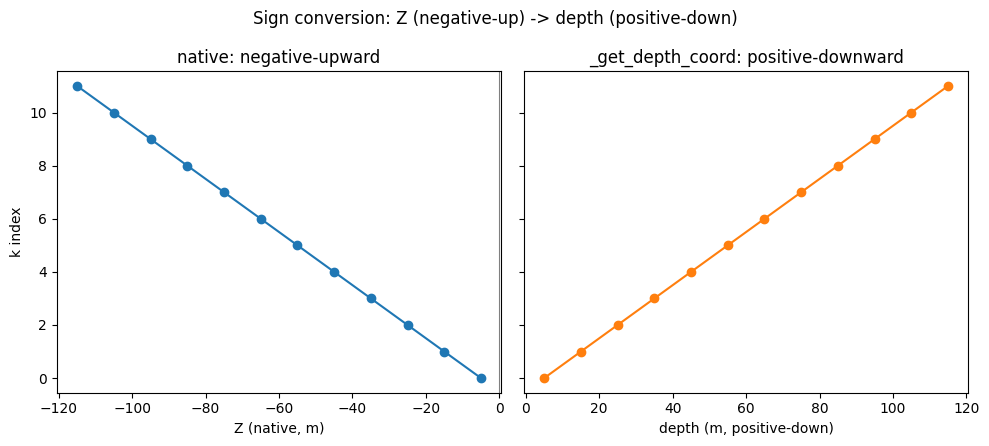

depth = -Z ? True


In [2]:
ds, z_pos = tvh.make_synthetic_vertical(nk=12, dz=10.0)
depth = vh._get_depth_coord(ds, zdim='k')
k = np.arange(ds.sizes['k'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
axes[0].plot(ds['Z'].values, k, 'o-')
axes[0].axvline(0, color='grey', lw=0.8)
axes[0].set_xlabel('Z (native, m)'); axes[0].set_ylabel('k index')
axes[0].set_title('native: negative-upward')
axes[1].plot(depth.values, k, 'o-', color='C1')
axes[1].set_xlabel('depth (m, positive-down)')
axes[1].set_title('_get_depth_coord: positive-downward')
for ax in axes:
    ax.invert_yaxis()
fig.suptitle('Sign conversion: Z (negative-up) -> depth (positive-down)')
fig.tight_layout(); plt.show()
print('depth = -Z ?', np.allclose(depth.values, -ds["Z"].values))


## 2. Vertical derivative & sign (offline)

`_vertical_derivative` is exact for a linear profile (forward /
centered / backward stencils all reproduce the slope). A profile
that *decreases* with depth gives `dθ/dz < 0` — the physically
meaningful sign with z positive-downward.

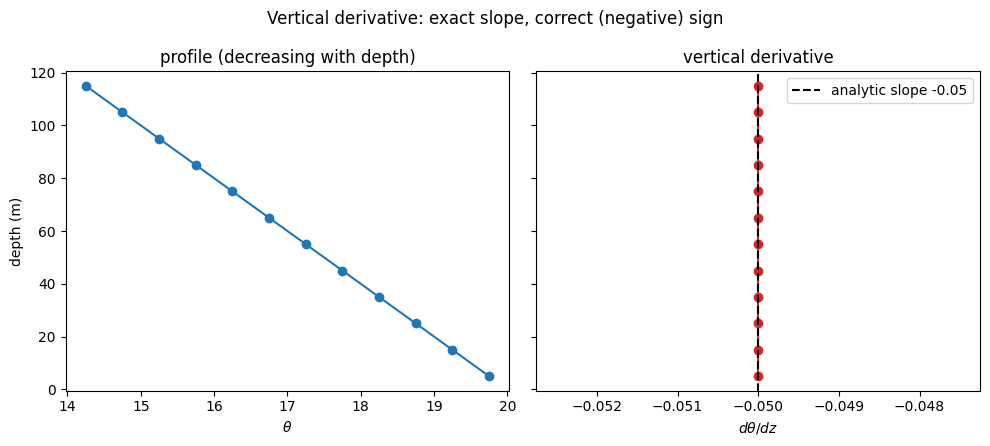

all dtheta/dz < 0 ? True | max |err| vs -0.05 = 0.0


In [3]:
ds, z_pos = tvh.make_synthetic_vertical(nk=12, dz=10.0)
theta = tvh.vertical_field(20.0 - 0.05 * z_pos)     # warm top, cool deep
dtheta = vh._vertical_derivative(theta, ds).isel(j=0, i=0).values
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
axes[0].plot(theta.isel(j=0, i=0).values, z_pos, 'o-')
axes[0].set_xlabel(r'$\theta$'); axes[0].set_ylabel('depth (m)')
axes[0].set_title('profile (decreasing with depth)')
axes[1].plot(dtheta, z_pos, 'o-', color='C3')
axes[1].axvline(-0.05, color='k', ls='--', label='analytic slope -0.05')
axes[1].set_xlabel(r'$d\theta/dz$'); axes[1].set_title('vertical derivative')
axes[1].legend()
for ax in axes:
    ax.invert_yaxis()
fig.suptitle('Vertical derivative: exact slope, correct (negative) sign')
fig.tight_layout(); plt.show()
print('all dtheta/dz < 0 ?', bool(np.all(dtheta < 0)),
      '| max |err| vs -0.05 =', float(np.abs(dtheta + 0.05).max()))


## 3. Layer thickness & mixed-layer mean (offline)

`_masked_ml_mean` is a thickness-weighted (`drF`) average over
`0 ≤ z ≤ MLD`. Here a linear profile is averaged down to a 55 m
mixed layer; the shaded band is the averaging region and the dashed
line is the computed weighted mean.

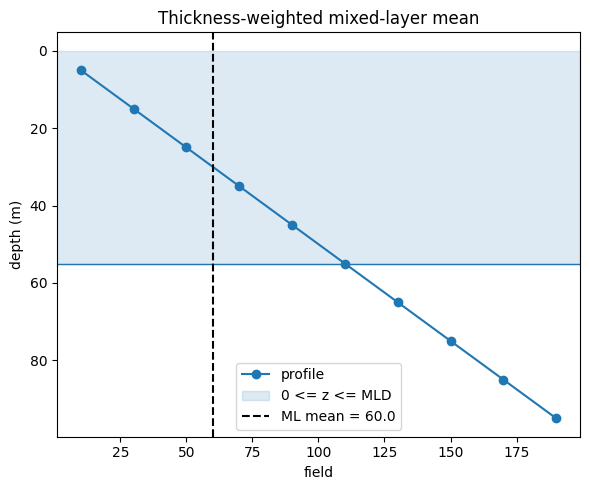

In [4]:
ds, z_pos = tvh.make_synthetic_vertical(nk=10, dz=10.0, nspace=1)
prof = 2.0 * z_pos
field = tvh.vertical_field(prof, nspace=1)
mld_depth = 55.0
mld = __import__('xarray').DataArray(np.full((1, 1), mld_depth),
                                     dims=('j', 'i'))
ml_mean = float(vh._masked_ml_mean(field, mld, ds).values.ravel()[0])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prof, z_pos, 'o-', label='profile')
ax.axhspan(0, mld_depth, color='C0', alpha=0.15, label='0 <= z <= MLD')
ax.axhline(mld_depth, color='C0', lw=1)
ax.axvline(ml_mean, color='k', ls='--', label=f'ML mean = {ml_mean:.1f}')
ax.invert_yaxis()
ax.set_xlabel('field'); ax.set_ylabel('depth (m)')
ax.set_title('Thickness-weighted mixed-layer mean')
ax.legend(); fig.tight_layout(); plt.show()


## 4. Real LLC4320 vertical structure (online)

The genuine 51-level grid (fetched once, cached): native `Z`
negative-upward, the converted positive-downward depth, and the
real layer thickness `drF`, which refines toward the surface
(~1 m near the top, tens of m at depth).

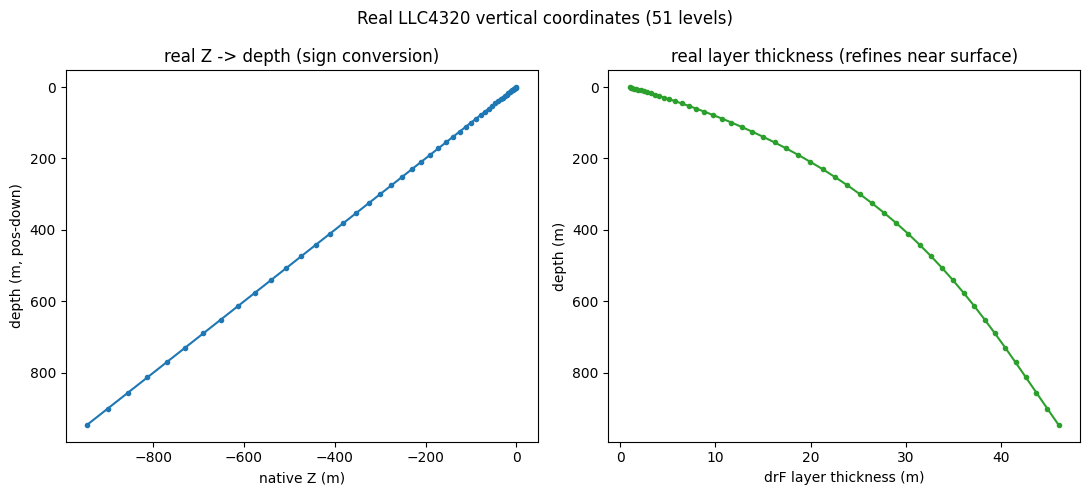

depth range 0.50 .. 945.6 m | drF range 1.00 .. 46.0 m
sum(drF) = 968.62 m  vs interface span = 968.62 m


In [5]:
dsr = tvh.load_real_llc_vertical()
depth_r = vh._get_depth_coord(dsr, zdim='k').values
drf_r = vh._get_vertical_spacing(dsr, zdim='k').values
k = np.arange(len(depth_r))
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(dsr['Z'].values, depth_r, 'o-', ms=3)
axes[0].set_xlabel('native Z (m)'); axes[0].set_ylabel('depth (m, pos-down)')
axes[0].invert_yaxis()
axes[0].set_title('real Z -> depth (sign conversion)')
axes[1].plot(drf_r, depth_r, 'o-', ms=3, color='C2')
axes[1].invert_yaxis()
axes[1].set_xlabel('drF layer thickness (m)'); axes[1].set_ylabel('depth (m)')
axes[1].set_title('real layer thickness (refines near surface)')
fig.suptitle('Real LLC4320 vertical coordinates (51 levels)')
fig.tight_layout(); plt.show()
print('depth range %.2f .. %.1f m | drF range %.2f .. %.1f m'
      % (depth_r.min(), depth_r.max(), drf_r.min(), drf_r.max()))
if 'Zp1' in dsr:
    span = abs(float(dsr['Zp1'].values[-1] - dsr['Zp1'].values[0]))
    print('sum(drF) = %.2f m  vs interface span = %.2f m'
          % (drf_r.sum(), span))


## 5. Vertical derivative on the real non-uniform grid (online)

Centered/forward/backward differences stay exact for a linear
profile even on the real non-uniform `Z` spacing: `f = slope·depth`
recovers `slope` at every level.

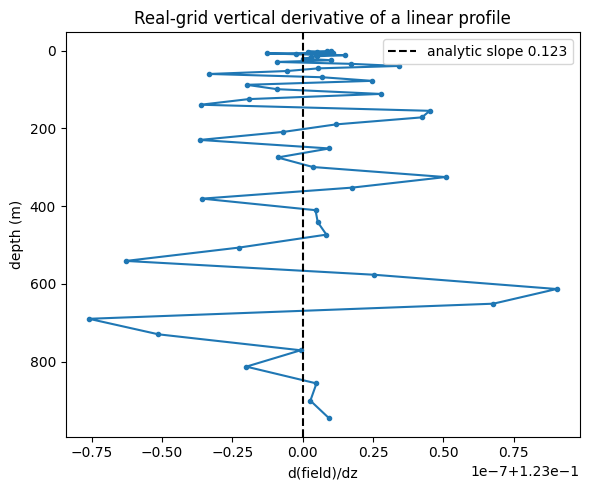

max |deriv - slope| = 9.03e-08


In [6]:
slope = 0.123
field_r = tvh.vertical_field(slope * depth_r)
deriv_r = vh._vertical_derivative(field_r, dsr).isel(j=0, i=0).values
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(deriv_r, depth_r, 'o-', ms=3)
ax.axvline(slope, color='k', ls='--', label=f'analytic slope {slope}')
ax.invert_yaxis()
ax.set_xlabel('d(field)/dz'); ax.set_ylabel('depth (m)')
ax.set_title('Real-grid vertical derivative of a linear profile')
ax.legend(); fig.tight_layout(); plt.show()
print('max |deriv - slope| = %.2e' % float(np.abs(deriv_r - slope).max()))


## 6. Run the test suite

Call the offline tests directly and the online tests with the
network gate enabled (the vertical-coordinate cache is tiny and
already present). No exception means they pass.

In [7]:
import os
tvh.test_get_vertical_dim_detection()
tvh.test_depth_coord_sign_conversion()
tvh.test_depth_coord_already_positive_is_unchanged()
tvh.test_depth_coord_renames_Z_dimension()
tvh.test_depth_coord_kl_uses_Zl()
tvh.test_vertical_spacing_uses_drF_for_tracer_levels()
tvh.test_vertical_spacing_fallback_to_gradient()
tvh.test_nearest_k_to_depth()
tvh.test_vertical_derivative_linear_is_exact()
tvh.test_vertical_derivative_sign_decreasing_with_depth()
tvh.test_select_at_depth_picks_nearest_level()
tvh.test_extract_at_mld_per_column()
tvh.test_interp_w_to_tracer_levels_averages_interfaces()
tvh.test_masked_ml_mean_constant_field()
tvh.test_masked_ml_mean_thickness_weighted()
print('offline tests passed.')

os.environ['RUN_LLC_NETWORK_TESTS'] = '1'  # cache already present
tvh.test_real_depth_coord_sign_and_monotonic()
tvh.test_real_vertical_spacing_drF_consistent()
tvh.test_real_vertical_derivative_linear_exact()
print('online tests passed.')


offline tests passed.
online tests passed.
